# Unit execution for `noise_sweep_plot.py` (method-comparison version)

This notebook checks the plotting helpers for:
- single-metric sweep plots
- fidelity + success-probability sweep plots
- DataFrame-driven sweep plots
- grouped sweep overlays
- **multi-method comparison plots** for:
  - paper SVD dilation
  - Sz.-Nagy dilation
  - unitary-only rescaled baseline

It assumes the updated `noise_sweep_plot.py` includes:
- `plot_method_comparison_dataframe(...)`
- `_plot_metric_vs_sweep_group_safe(...)`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from noise_sweep_plot import (
    SweepPlotColumns,
    default_sweep_xlabel,
    plot_metric_vs_sweep,
    plot_fidelity_and_success_vs_sweep,
    plot_results_dataframe,
    plot_grouped_results_dataframe,
    plot_method_comparison_dataframe,
)


## 1. Tweakable manual sweep arrays

In [2]:
sweep_values = np.array([0.00, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10])

fidelity_values = np.array([0.998, 0.992, 0.984, 0.962, 0.935, 0.901, 0.862])
fidelity_std = np.array([0.001, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008])

success_values = np.array([0.995, 0.989, 0.978, 0.955, 0.927, 0.892, 0.845])
success_std = np.array([0.001, 0.002, 0.002, 0.004, 0.005, 0.006, 0.009])

xlabel = default_sweep_xlabel("depolarizing")
print("x-axis label:", xlabel)


x-axis label: Depolarizing probability


## 2. Plot one metric only

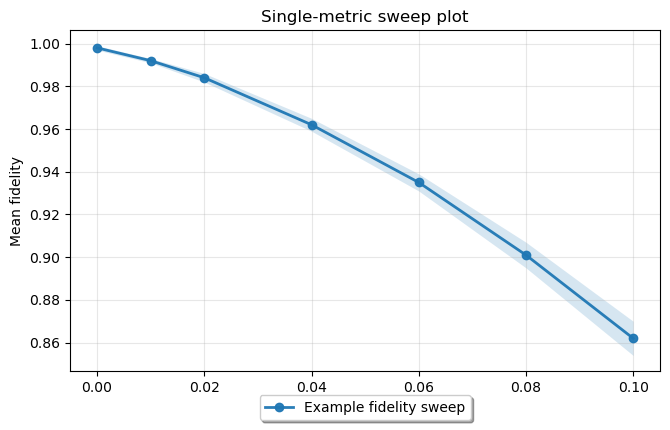

In [3]:
fig, ax = plot_metric_vs_sweep(
    sweep_values,
    fidelity_values,
    metric_std=fidelity_std,
    xlabel=xlabel,
    ylabel="Mean fidelity",
    label="Example fidelity sweep",
    title="Single-metric sweep plot",
)
plt.show()


## 3. Plot fidelity and success probability together

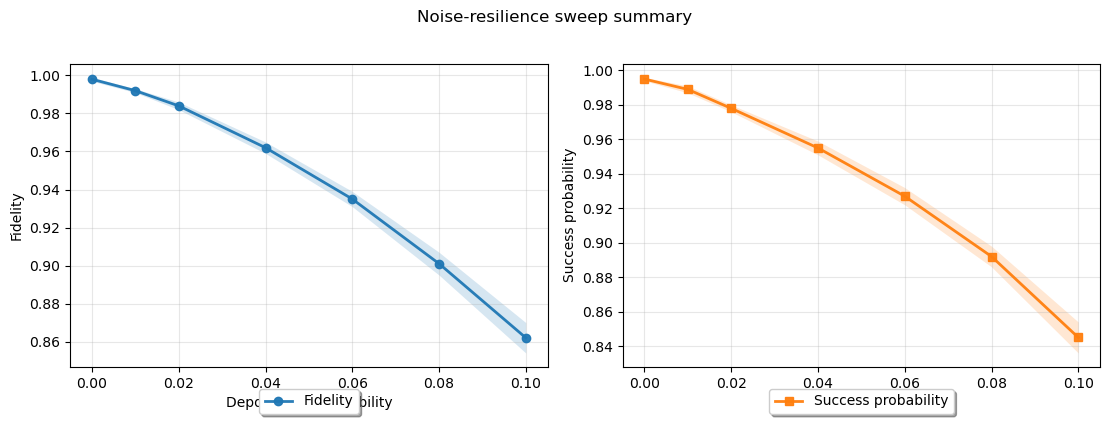

In [4]:
fig, axs = plot_fidelity_and_success_vs_sweep(
    sweep_values,
    fidelity_values,
    success_values,
    fidelity_std=fidelity_std,
    success_std=success_std,
    xlabel=xlabel,
    title="Noise-resilience sweep summary",
    colors=["tab:blue", "tab:orange"],
)
plt.show()


## 4. Plot from a standard results DataFrame

In [5]:
results_df = pd.DataFrame({
    "sweep_value": sweep_values,
    "fidelity_mean": fidelity_values,
    "fidelity_std": fidelity_std,
    "success_probability_mean": success_values,
    "success_probability_std": success_std,
    "label": ["Depolarizing sweep"] * len(sweep_values),
})

results_df


,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std,label
0,0.00,0.998,0.001,0.995,0.001,Depolarizing sweep
1,0.01,0.992,0.001,0.989,0.002,Depolarizing sweep
2,0.02,0.984,0.002,0.978,0.002,Depolarizing sweep
3,0.04,0.962,0.003,0.955,0.004,Depolarizing sweep
4,0.06,0.935,0.004,0.927,0.005,Depolarizing sweep
5,0.08,0.901,0.006,0.892,0.006,Depolarizing sweep
6,0.10,0.862,0.008,0.845,0.009,Depolarizing sweep


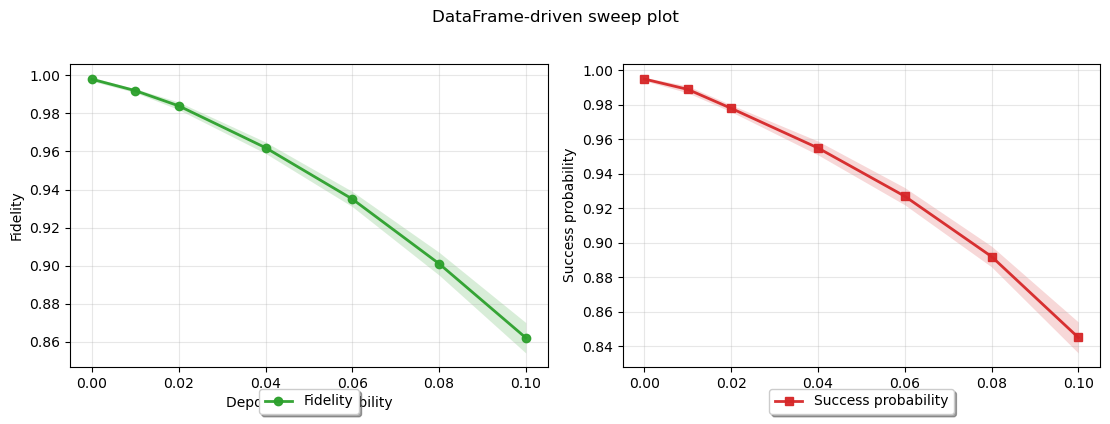

In [6]:
fig, axs = plot_results_dataframe(
    results_df,
    columns=SweepPlotColumns(label="label"),
    xlabel=xlabel,
    title="DataFrame-driven sweep plot",
    colors=["tab:green", "tab:red"],
)
plt.show()


## 5. Grouped overlay plot from a DataFrame

In [7]:
grouped_df = pd.DataFrame({
    "noise_kind": (["Amplitude damping"] * len(sweep_values)) + (["Phase damping"] * len(sweep_values)),
    "sweep_value": np.concatenate([sweep_values, sweep_values]),
    "fidelity_mean": np.concatenate([
        fidelity_values,
        np.array([0.997, 0.993, 0.987, 0.972, 0.954, 0.932, 0.905]),
    ]),
    "fidelity_std": np.concatenate([
        fidelity_std,
        np.array([0.001, 0.001, 0.0015, 0.002, 0.003, 0.004, 0.005]),
    ]),
    "success_probability_mean": np.concatenate([
        success_values,
        np.array([0.996, 0.991, 0.982, 0.966, 0.946, 0.920, 0.889]),
    ]),
    "success_probability_std": np.concatenate([
        success_std,
        np.array([0.001, 0.0015, 0.002, 0.003, 0.004, 0.005, 0.006]),
    ]),
})

grouped_df.head()


,noise_kind,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
0,Amplitude damping,0.00,0.998,0.001,0.995,0.001
1,Amplitude damping,0.01,0.992,0.001,0.989,0.002
2,Amplitude damping,0.02,0.984,0.002,0.978,0.002
3,Amplitude damping,0.04,0.962,0.003,0.955,0.004
4,Amplitude damping,0.06,0.935,0.004,0.927,0.005


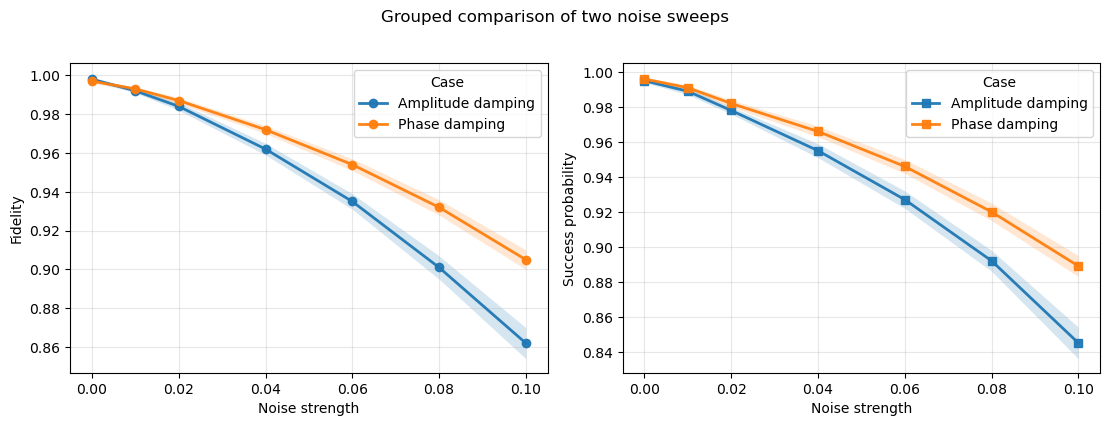

In [8]:
fig, axs = plot_grouped_results_dataframe(
    grouped_df,
    group_column="noise_kind",
    xlabel="Noise strength",
    title="Grouped comparison of two noise sweeps",
    colors=["tab:blue", "tab:orange"],
    legend_title="Case",
)
plt.show()


## 6. Multi-method comparison: flat success probability baseline

In [9]:
comparison_summary_df = pd.DataFrame({
    "method": (
        ["paper_svd"] * len(sweep_values)
        + ["sz_nagy"] * len(sweep_values)
        + ["unitary_rescaled"] * len(sweep_values)
    ),
    "sweep_value": list(sweep_values) * 3,
    "fidelity_mean": np.concatenate([
        np.array([0.995, 0.988, 0.978, 0.955, 0.925, 0.890, 0.845]),
        np.array([0.997, 0.992, 0.984, 0.968, 0.945, 0.915, 0.875]),
        np.array([0.985, 0.975, 0.960, 0.935, 0.900, 0.860, 0.810]),
    ]),
    "fidelity_std": np.concatenate([
        np.array([0.002, 0.002, 0.003, 0.004, 0.005, 0.007, 0.009]),
        np.array([0.001, 0.0015, 0.002, 0.003, 0.004, 0.006, 0.008]),
        np.array([0.003, 0.004, 0.005, 0.006, 0.008, 0.010, 0.012]),
    ]),
    "success_probability_mean": np.concatenate([
        np.array([0.63, 0.61, 0.58, 0.54, 0.49, 0.44, 0.39]),
        np.array([0.69, 0.67, 0.64, 0.60, 0.55, 0.49, 0.43]),
        np.ones(len(sweep_values)),
    ]),
    "success_probability_std": np.concatenate([
        np.array([0.010, 0.011, 0.013, 0.016, 0.019, 0.022, 0.025]),
        np.array([0.009, 0.010, 0.011, 0.014, 0.017, 0.020, 0.024]),
        np.zeros(len(sweep_values)),
    ]),
})

comparison_summary_df.head(10)


,method,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
0,paper_svd,0.00,0.995,0.0020,0.63,0.010
1,paper_svd,0.01,0.988,0.0020,0.61,0.011
2,paper_svd,0.02,0.978,0.0030,0.58,0.013
3,paper_svd,0.04,0.955,0.0040,0.54,0.016
4,paper_svd,0.06,0.925,0.0050,0.49,0.019
5,paper_svd,0.08,0.890,0.0070,0.44,0.022
6,paper_svd,0.10,0.845,0.0090,0.39,0.025
7,sz_nagy,0.00,0.997,0.0010,0.69,0.009
8,sz_nagy,0.01,0.992,0.0015,0.67,0.010
9,sz_nagy,0.02,0.984,0.0020,0.64,0.011


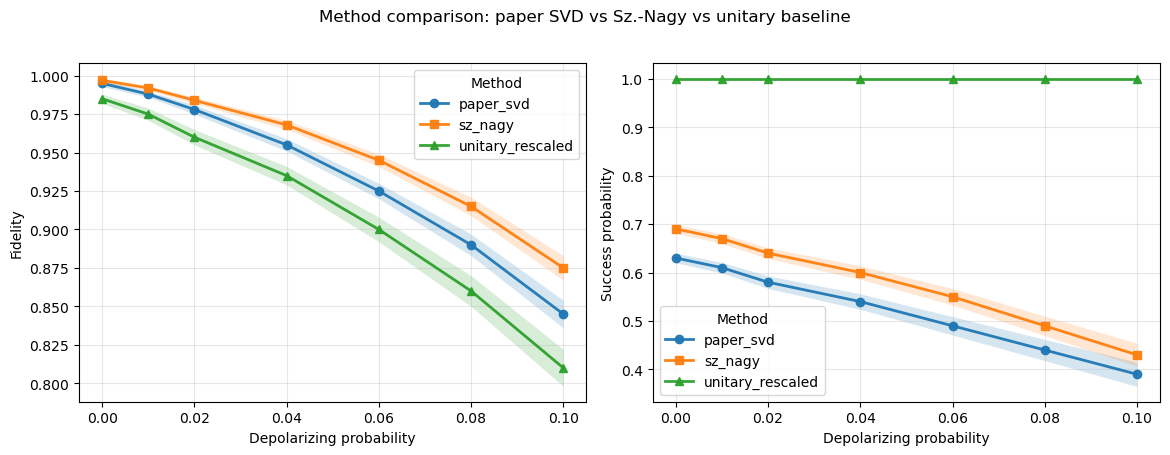

In [10]:
fig, axs = plot_method_comparison_dataframe(
    comparison_summary_df,
    method_column="method",
    columns=SweepPlotColumns(
        sweep_value="sweep_value",
        fidelity_mean="fidelity_mean",
        fidelity_std="fidelity_std",
        success_mean="success_probability_mean",
        success_std="success_probability_std",
    ),
    xlabel=default_sweep_xlabel("depolarizing"),
    title="Method comparison: paper SVD vs Sz.-Nagy vs unitary baseline",
    colors=["tab:blue", "tab:orange", "tab:green"],
    markers=["o", "s", "^"],
    legend_title="Method",
)
plt.show()


## 7. Multi-method comparison: unitary baseline with NaN success probability

In [11]:
comparison_summary_nan_df = comparison_summary_df.copy()
mask = comparison_summary_nan_df["method"] == "unitary_rescaled"
comparison_summary_nan_df.loc[mask, "success_probability_mean"] = np.nan
comparison_summary_nan_df.loc[mask, "success_probability_std"] = np.nan

comparison_summary_nan_df[comparison_summary_nan_df["method"] == "unitary_rescaled"].head()


,method,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
14,unitary_rescaled,0.00,0.985,0.003,NaN,NaN
15,unitary_rescaled,0.01,0.975,0.004,NaN,NaN
16,unitary_rescaled,0.02,0.960,0.005,NaN,NaN
17,unitary_rescaled,0.04,0.935,0.006,NaN,NaN
18,unitary_rescaled,0.06,0.900,0.008,NaN,NaN


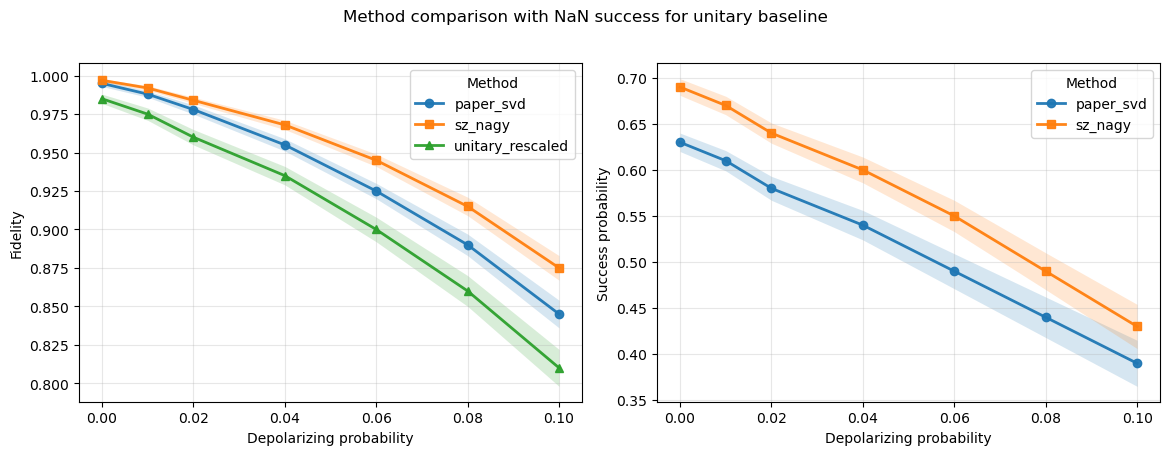

In [12]:
fig, axs = plot_method_comparison_dataframe(
    comparison_summary_nan_df,
    method_column="method",
    columns=SweepPlotColumns(
        sweep_value="sweep_value",
        fidelity_mean="fidelity_mean",
        fidelity_std="fidelity_std",
        success_mean="success_probability_mean",
        success_std="success_probability_std",
    ),
    xlabel=default_sweep_xlabel("depolarizing"),
    title="Method comparison with NaN success for unitary baseline",
    colors=["tab:blue", "tab:orange", "tab:green"],
    markers=["o", "s", "^"],
    legend_title="Method",
)
plt.show()


## 8. Minimal template for your future resilience notebooks

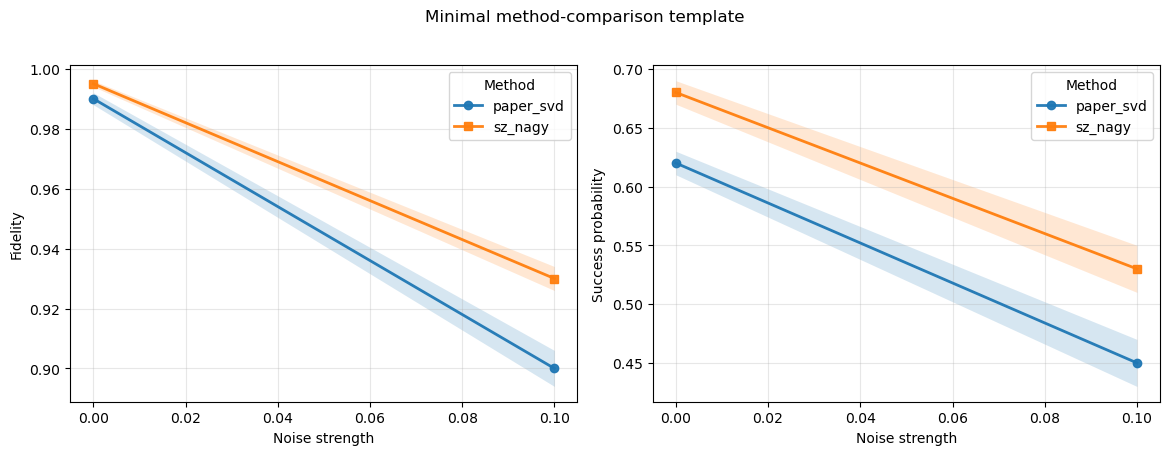

In [13]:
my_comparison_df = pd.DataFrame({
    "method": ["paper_svd", "paper_svd", "sz_nagy", "sz_nagy"],
    "sweep_value": [0.0, 0.1, 0.0, 0.1],
    "fidelity_mean": [0.99, 0.90, 0.995, 0.93],
    "fidelity_std": [0.002, 0.006, 0.001, 0.004],
    "success_probability_mean": [0.62, 0.45, 0.68, 0.53],
    "success_probability_std": [0.01, 0.02, 0.01, 0.02],
})

fig, axs = plot_method_comparison_dataframe(
    my_comparison_df,
    method_column="method",
    columns=SweepPlotColumns(
        sweep_value="sweep_value",
        fidelity_mean="fidelity_mean",
        fidelity_std="fidelity_std",
        success_mean="success_probability_mean",
        success_std="success_probability_std",
    ),
    xlabel="Noise strength",
    title="Minimal method-comparison template",
)
plt.show()
